In [73]:
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import rasterio as rio
import rasterio.mask as rio_mask

In [2]:
data_path = Path(os.environ["DATA_PATH"])

In [3]:
df = (
    gpd.read_file(data_path / "USOS_DE_SUELO_EXITS_24")
    .filter(["USOSUELO24", "geometry"])
    .assign(geometry=lambda df: df["geometry"].force_2d())
    .assign(geometry=lambda df: df["geometry"].centroid)
    .to_crs("EPSG:4326")
)

In [ ]:
out = {}
with rio.open("./final_raster.tif") as ds:
    for idx, geom in df["geometry"].items():
        masked, _ = rio_mask.mask(ds, [geom], crop=True)
        out[idx] = masked.squeeze().item()

In [70]:
df = df.assign(category=pd.Series(out)).assign(
    category=lambda df: df["category"].map(
        {3: "0 - Templado", 4: "1 - Ligeramente caliente", 5: "2 - Caliente"},
    ),
)

In [71]:
test = (
    df.groupby(["USOSUELO24", "category"])["geometry"]
    .count()
    .reset_index()
    .pivot_table(
        index="USOSUELO24",
        columns="category",
        values="geometry",
        fill_value=0,
    )
)
test = test.div(test.sum(axis=1), axis=0).sort_index(ascending=False)

(0.0, 1.0)

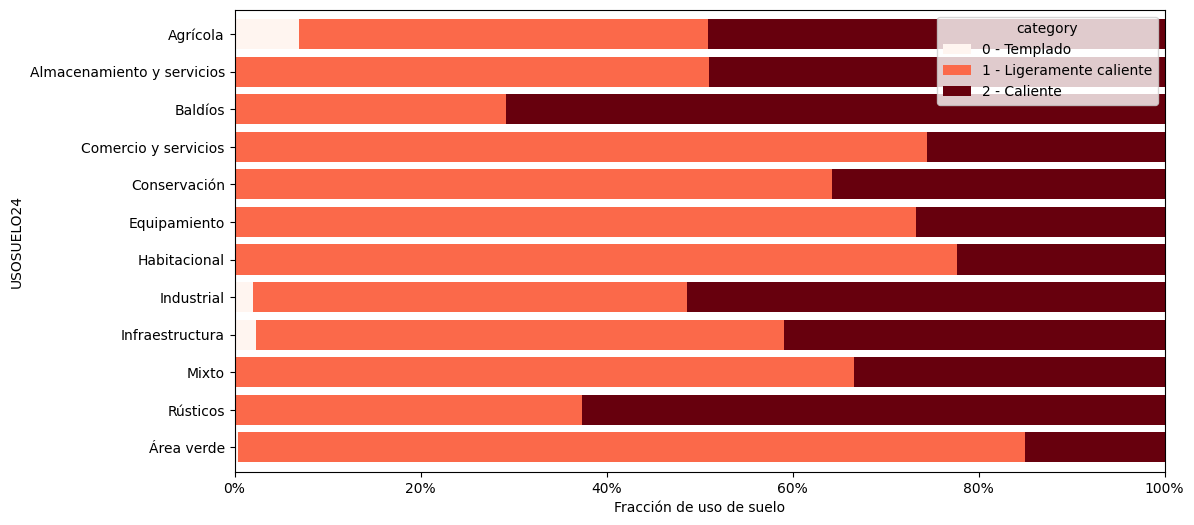

In [76]:
fig, ax = plt.subplots(figsize=(12, 6))
test.plot.barh(stacked=True, cmap="Reds", ax=ax, width=0.8)
ax.set_xlabel("Fracción de uso de suelo")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set_xlim(0, 1)